In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import os

with open (r"D:\10135\S1_20260216_171630\suite2p\combined\stat.npy", "rb") as f:
    stat = np.load(f, allow_pickle=True)
    
with open(r"D:\10135\S1_20260216_171630\suite2p\combined\ops.npy", "rb") as f:
    ops = np.load(f, allow_pickle=True)

dict_keys(['suite2p_version', 'look_one_level_down', 'fast_disk', 'delete_bin', 'mesoscan', 'bruker', 'bruker_bidirectional', 'h5py', 'h5py_key', 'nwb_file', 'nwb_driver', 'nwb_series', 'save_path0', 'save_folder', 'subfolders', 'move_bin', 'nplanes', 'nchannels', 'functional_chan', 'tau', 'fs', 'force_sktiff', 'frames_include', 'multiplane_parallel', 'ignore_flyback', 'preclassify', 'save_mat', 'save_NWB', 'combined', 'aspect', 'do_bidiphase', 'bidiphase', 'bidi_corrected', 'do_registration', 'two_step_registration', 'keep_movie_raw', 'nimg_init', 'batch_size', 'maxregshift', 'align_by_chan', 'reg_tif', 'reg_tif_chan2', 'subpixel', 'smooth_sigma_time', 'smooth_sigma', 'th_badframes', 'norm_frames', 'force_refImg', 'pad_fft', 'nonrigid', 'block_size', 'snr_thresh', 'maxregshiftNR', '1Preg', 'spatial_hp_reg', 'pre_smooth', 'spatial_taper', 'roidetect', 'spikedetect', 'sparse_mode', 'spatial_scale', 'connected', 'nbinned', 'max_iterations', 'threshold_scaling', 'max_overlap', 'high_pass'

<>:23: SyntaxWarning: invalid escape sequence '\S'
<>:23: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5916\979828551.py:23: SyntaxWarning: invalid escape sequence '\S'
  path = r"D:\10135\S1_20260216_171630\suite2p\combined\mean_images"


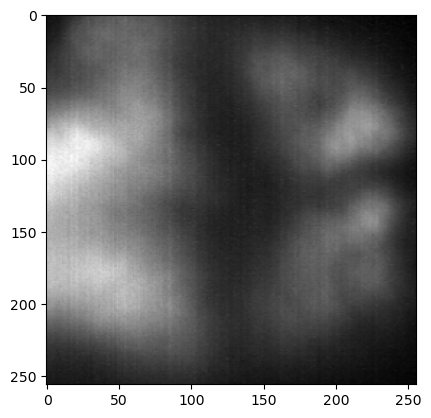

In [2]:
obj = ops.item()      # or: obj = ops[()]
print(obj.keys())
print(obj['meanImg'].shape)
print(obj['lenX'], obj['lenY'], obj['lenZ'])
r = 3
c = 3
x = 1600
y = 340
# convert and save as .tif

"""
a = []
for r in range(100):
    for c in range(5):
        try:
            
            a.append(obj['meanImg'][np.ix_(np.arange(2304*r, 2304*r+1152), np.arange(2304*c, 2304*(c+1)))])
        except:
            break
a = np.stack(a, axis=2).T
"""
"""
path = r"D:\10135\S1_20260216_171630\suite2p\combined\mean_images"
mkdir(path)

for r in range(100):
    for c in range(5):
        try:
            a = obj['meanImg'][np.ix_(np.arange(2304*r, 2304*r+1152), np.arange(2304*c, 2304*(c+1)))]
            tiff.imwrite(join(path, f"mean_image_{r*5+c}.tif"), np.stack([a, a, a], axis=2))
        except: 
            break
"""
a = obj['meanImg'][np.ix_(np.arange(2304*r, 2304*r+1152), np.arange(2304*c, 2304*(c+1)))][
    np.ix_(np.arange(y, y+256), np.arange(x, x+256))
]
plt.imshow(a, cmap='gray')
plt.show()

In [3]:
param_list = [
    (0, 1, 1100, 400),
    (0, 2, 960, 550),
    (0, 2, 1120, 200),
    (0, 3, 1160, 380),
    (0, 3, 1560, 380),
    (0, 4, 1640, 340),
    (0, 4, 1260, 380),
    (0, 4, 820, 600),
    (1, 0, 1720, 180),
    (1, 0, 1720, 440),
    (1, 0, 550, 400),
    (1, 1, 1750, 300),
    (1, 1, 1200, 380),
    (1, 2, 550, 450),
    (1, 2, 1820, 320),
    (1, 3, 1820, 300),
    (1, 3, 1350, 360),
    (1, 4, 1820, 300),
    (1, 4, 420, 330),
    #(2, 0, 420, 110),
    (2, 0, 420, 290),
    (2, 0, 1860, 300),
    (2, 1, 1860, 290),
    (2, 1, 200, 500),
    (2, 1, 1100, 200),
    (2, 2, 400, 300),
    (2, 2, 1020, 100),
    (2, 3, 950, 700),
    (2, 3, 1850, 310),
    (2, 4, 400, 460),
    (3, 0, 450, 450),
    (3, 1, 630, 420),
    (3, 2, 480, 450),
    (3, 3, 280, 420),
    (3, 3, 930, 70),
    (3, 4, 310, 440),
    (3, 4, 1400, 370),
    (3, 3, 1600, 340)
]
import os
path = r"D:\10135\S1_20260216_171630\suite2p\combined\training_set"
image = np.zeros((8*256, 5*256))
for i, param in enumerate(param_list):
    if i >= 37:
        break
    row, col = i // 5, i % 5
    r, c, x, y = param
    a = obj['meanImg'][np.ix_(np.arange(2304*r, 2304*r+1152), np.arange(2304*c, 2304*(c+1)))][
        np.ix_(np.arange(y, y+256), np.arange(x, x+256))
    ]
    image[row*256:(row+1)*256, col*256:(col+1)*256] = a
    tiff.imwrite(os.path.join(path, f"image_{i}.tif"), np.stack([a, a, a], axis=2))
    
    if not os.path.exists(path):
        os.makedirs(path)

tiff.imwrite(os.path.join(path, f"image_combined.tif"), np.stack([image, image, image], axis=2))

In [4]:
seg_file = {
    "outlines": np.zeros((8*256, 5*256), dtype=np.uint16),
    "colors": [],
    "masks": np.zeros((8*256, 5*256), dtype=np.uint16),  
    "filename": os.path.join(path, f"image_combined.tif"),
    "flows": [],
    "ismanual": [],
    "manual_changes": [],
    "model_path": 0,
    "flow_threshold": 0.4,
    "cellprob_threshold": 0.0,
    "normalize_params": {'lowhigh': None, 'percentile': [1.0, 99.0], 'normalize': True, 'norm3D': True, 'sharpen_radius': 0.0, 'smooth_radius': 0.0, 'tile_norm_blocksize': 0.0, 'tile_norm_smooth3D': 1.0, 'invert': False},
    "restore": None,
    "ratio": 1.0,
    "diameter": None
}

for i in range(37):
    row, col = i // 5, i % 5
    
    with open(os.path.join(path, f"image_{i}_seg.npy"), "rb") as f:
        seg = np.load(f, allow_pickle=True).item()
    seg_file["outlines"][row*256:(row+1)*256, col*256:(col+1)*256] = seg["outlines"]
    seg_file["colors"].append(seg["colors"])
    seg_file["masks"][row*256:(row+1)*256, col*256:(col+1)*256] = seg["masks"]
    seg_file["flows"].extend(seg["flows"])
    seg_file["ismanual"].append(seg["ismanual"])
    seg_file["manual_changes"].extend(seg["manual_changes"])
    
seg_file["colors"] = np.vstack(seg_file["colors"]).astype(np.uint8)
seg_file['ismanual'] = np.concatenate(seg_file['ismanual'])

print(seg_file['outlines'].shape, np.sum(seg_file['outlines']))
print(seg_file['filename'])
print(seg_file['model_path'], seg_file['flow_threshold'], seg_file['cellprob_threshold'], seg_file['normalize_params'], seg_file['restore'], seg_file['ratio'], seg_file['diameter'])
for k in seg_file.keys():
    print(k, type(seg_file[k]), end=' ')
    try:
        print(seg_file[k].dtype, seg_file[k].shape)
    except:        print()
    
with open(os.path.join(path, f"image_combined_seg.npy"), "wb") as f:
    np.save(f, seg_file)

(2048, 1280) 19085460
D:\10135\S1_20260216_171630\suite2p\combined\training_set\image_combined.tif
0 0.4 0.0 {'lowhigh': None, 'percentile': [1.0, 99.0], 'normalize': True, 'norm3D': True, 'sharpen_radius': 0.0, 'smooth_radius': 0.0, 'tile_norm_blocksize': 0.0, 'tile_norm_smooth3D': 1.0, 'invert': False} None 1.0 None
outlines <class 'numpy.ndarray'> uint16 (2048, 1280)
colors <class 'numpy.ndarray'> uint8 (5982, 3)
masks <class 'numpy.ndarray'> uint16 (2048, 1280)
filename <class 'str'> 
flows <class 'list'> 
ismanual <class 'numpy.ndarray'> bool (5982,)
manual_changes <class 'list'> 
model_path <class 'int'> 
flow_threshold <class 'float'> 
cellprob_threshold <class 'float'> 
normalize_params <class 'dict'> 
restore <class 'NoneType'> 
ratio <class 'float'> 
diameter <class 'NoneType'> 
